In [1]:
import os
from pathlib import Path
import nugraph as ng
import h5py
import numpy as np

import networkx as nx
import torch
import torch_geometric.data
import matplotlib.pyplot as plt

In [2]:
Data = ng.data.NuGraphDataModule
Model = ng.models.NuGraph3

In [ ]:
# this should be a h5 file with 3d edges ideally
## this file has 3d delaunay 
# path="/exp/sbnd/app/users/lynnt/dl-clustering/nugraph/pywcml/sample/test3d_666.h5"
## this file has 3d ppedges
path="/exp/sbnd/app/users/lynnt/dl-clustering/nugraph/pywcml/sample/test_ppedges.h5"
nudata = Data(model=Model, data_path=path)

## visualize 2D edges

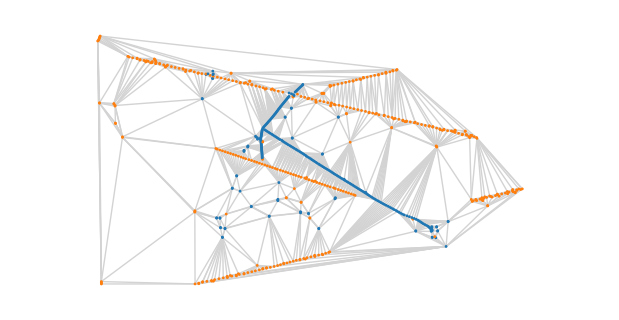

In [18]:
evt = nudata.train_dataset[3]
# get 2d edge indices 
edge_index = evt[('hit','delaunay-planar','hit')].edge_index
x = evt['hit']
# choose the collection plane (can also choose induction planes )
# apply the mask to only get nodes and edges for the collection plane
mask = x.plane==0
subset_nodes = mask.nonzero(as_tuple=False).view(-1)
subedge_index, _ = torch_geometric.utils.subgraph(subset_nodes, edge_index, relabel_nodes=True)
data_sub = torch_geometric.data.Data(x=x.x[subset_nodes], edge_index=subedge_index)
# carry over other features
data_sub['y_semantic'] = x['y_semantic'][subset_nodes]

# call networkx 
g = torch_geometric.utils.to_networkx(data_sub, to_undirected=True)
pos = {i: data_sub.x[i, :2].numpy()[::-1] for i in range(data_sub.num_nodes)}

plt.figure(figsize=(6, 3))
nx.draw(
    g,
    pos=pos,
    node_size=1,
    node_color=np.where(data_sub.y_semantic.numpy()==1, "C1", "C0"),   
    edge_color='lightgray',
    with_labels=False,
    hide_ticks=False,
)
plt.axis('equal')  # keep aspect ratio
# plt.xlim(140,350)
# plt.ylim(100,250)

plt.show()


## visualize 3D

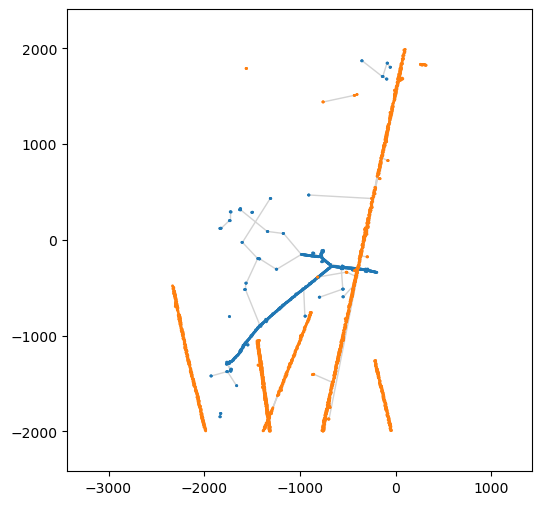

In [19]:
edge_index = evt[('sp','nexus','sp')].edge_index
data = evt['sp']
# this mask doesn't do anything
mask = data.y_semantic<2
subset_nodes = mask.nonzero(as_tuple=False).view(-1)
subedge_index, _ = torch_geometric.utils.subgraph(subset_nodes, edge_index, relabel_nodes=True)
data_sub = torch_geometric.data.Data(x=data.x[subset_nodes], edge_index=subedge_index)
# carry over other features
data_sub['y_semantic'] = data['y_semantic'][subset_nodes]
data_sub['pos'] = data['pos'][subset_nodes]

g = torch_geometric.utils.to_networkx(data_sub, to_undirected=True)
# you can change which set of xyz coordinates here
pos = {i: data_sub.pos[i, 0:2].numpy() for i in range(data_sub.num_nodes)}

fig, ax = plt.subplots(figsize=(6,6))
nx.draw_networkx(
    g,
    pos=pos,
    node_size=1,
    node_color=np.where(data_sub.y_semantic.numpy()==1, "C1", "C0"),
    edge_color='lightgray',
    with_labels=False,
    hide_ticks=False,
)
plt.axis('equal')
plt.show()

## visualize OG nugraph (2D only)

/exp/sbnd/data/users/lynnt/conda/conda_envs/dlclus/lib/python3.12/site-packages/torch_geometric/data/storage.py:452: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'y_vtx', 'y'}'. Please explicitly set 'num_nodes' as an attribute of 'data[evt]' to suppress this warning
  warnings.warn(


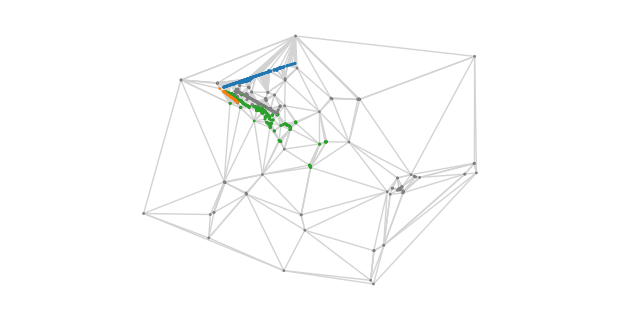

In [ ]:
path="/scratch/7DayLifetime/abhat/wirecell/clustering/nugraph_logs/NG2-paper.gnn.h5"
nudata = Data(model=Model, data_path=path)
evt = nudata.train_dataset[3]
# get 2d edge indices 
edge_index = evt[('hit','delaunay-planar','hit')].edge_index
x = evt['hit']
# choose the collection plane (can also choose induction planes )
# apply the mask to only get nodes and edges for the collection plane
mask = x.plane==2
subset_nodes = mask.nonzero(as_tuple=False).view(-1)
subedge_index, _ = torch_geometric.utils.subgraph(subset_nodes, edge_index, relabel_nodes=True)
data_sub = torch_geometric.data.Data(x=x.x[subset_nodes], edge_index=subedge_index)
# carry over other features
data_sub['y_semantic'] = x['y_semantic'][subset_nodes]

# call networkx 
g = torch_geometric.utils.to_networkx(data_sub, to_undirected=True)
pos = {i: data_sub.x[i, :2].numpy() for i in range(data_sub.num_nodes)}

# they have more semantic lables 
node_color = np.zeros(len(data_sub.y_semantic))
node_color = np.where(data_sub.y_semantic.numpy()==-1, "gray", node_color)
node_color = np.where(data_sub.y_semantic.numpy()==0, "C0", node_color)
node_color = np.where(data_sub.y_semantic.numpy()==1, "C1", node_color)
node_color = np.where(data_sub.y_semantic.numpy()==2, "C2", node_color)
node_color = np.where(data_sub.y_semantic.numpy()==3, "C3", node_color)
node_color = np.where(data_sub.y_semantic.numpy()==4, "C4", node_color)

plt.figure(figsize=(6, 3))
nx.draw(
    g,
    pos=pos,
    node_size=1,
    node_color=node_color,
    edge_color='lightgray',
    with_labels=False,
    hide_ticks=False,
)
plt.axis('equal')  # keep aspect ratio
plt.show()

